In [1]:
!pip install emcee

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 805.8 kB/s eta 0:00:00


In [2]:
import numpy as np
import emcee
import random
import warnings

In [3]:
warnings.simplefilter('ignore')

########################
###### parameters ######
########################

# Number of walkers in MCMC sampling
nwalkers = 50

# Number of step in MCMC sampling
nstep = 10

# The value of T in probability distribuion
Temp=1.0/np.e**5


In [4]:
#####################################
##### Training regression model #####
#####################################

# Data input
def load_data():
    A =  np.asarray( np.loadtxt('/content/target elongation.csv',skiprows=1,delimiter=',') )
    X = A[:,0:-1]
    t = A[:,-1]

    return X, t

Xdata, t = load_data()

total_dim_feature=len(Xdata[0])

t_max=max(t)
t_min=min(t)


In [5]:
# Standardization
def new_centering(A, B):
    stdA = np.std(A, 0)   # calculate standard deviation of A
    indexA = np.where(stdA !=0)
    return (B[:,indexA[0]] - np.mean(A[:,indexA[0]],0))/stdA[indexA[0]],np.mean(A[:,indexA[0]],0),stdA[indexA[0]]

X,mean,std=new_centering(Xdata,Xdata)

In [6]:
# Regression model: Elastic net regression
def ElasticNet(X,t):

    from sklearn.model_selection import GridSearchCV
    from sklearn import linear_model

    enr =  linear_model.ElasticNet(max_iter=2)
    alpha_num = 31
    log_alpha = np.logspace(-2,1,alpha_num)
    alpha_list = np.append(log_alpha,0)
    parameters = {'alpha': alpha_list}

    clf = GridSearchCV(enr,parameters,cv=len(t),scoring='neg_mean_squared_error')

    clf.fit(X,t)

    return clf

In [7]:
# Regression
regression_model = ElasticNet(X,t)
alpha_opt = regression_model.best_params_


#####################################



###############################
######## MCMC sampling ########
###############################


comp_min=Xdata.min(axis=0)
comp_max=Xdata.max(axis=0)


ndim = total_dim_feature  # Number of parameters

In [8]:
# prepare initial state
p0=[]

for i in range(nwalkers):

    point=[]

    for j in range(total_dim_feature):

        point.append((comp_max[j]-comp_min[j])*random.random()+comp_min[j])


    p0.append(point)

In [9]:
# prior distribution
def lnprior(comp):

    #conservative prior

    for i in range(total_dim_feature):

        if comp_min[i] > comp[i] or comp[i] > comp_max[i]:
            return -np.inf

    return 0.0

In [10]:
# probability distribution to obtain higher property
def lnprob_high(comp):

    comp_new=[]

    for j in range(total_dim_feature):

        comp_new.append(comp[j])


    comp=comp_new

    test=[(comp-mean)/std,(comp-mean)/std]

    delta=regression_model.predict(test)

    lp=lnprior(comp)
    if not np.isfinite(lp):
        return -np.inf


    each=[]

    for i in range(len(comp)):
        each.append(comp[i])

    each.append(delta[0])

    sampling_high.append(each)

    return lp-(t_max-delta[0])/(t_max-t_min)/Temp

In [11]:
# probability distribution to obtain lower property
def lnprob_low(comp):

    comp_new=[]

    for j in range(total_dim_feature):

        comp_new.append(comp[j])


    comp=comp_new

    test=[(comp-mean)/std,(comp-mean)/std]

    delta=regression_model.predict(test)

    lp=lnprior(comp)
    if not np.isfinite(lp):
        return -np.inf


    each=[]

    for i in range(len(comp)):
        each.append(comp[i])

    each.append(delta[0])

    sampling_low.append(each)

    return lp-(delta[0]-t_min)/(t_max-t_min)/Temp

In [12]:
#MCMC to obtain higher property
sampling_high = []
sampler = emcee.EnsembleSampler(nwalkers,ndim,lnprob_high)
pos, prob, state = sampler.run_mcmc(p0,nstep)


f1=open('sampling_high.txt', 'w')

for x in sampling_high:

    for i in range(total_dim_feature+1):

        f1.write(str('%30.15f' % x[i]))
        if i!=total_dim_feature: f1.write('\t')
    f1.write('\n')

f1.close()


In [13]:
#MCMC to obtain lower property
sampling_low = []
sampler = emcee.EnsembleSampler(nwalkers,ndim,lnprob_low)
pos, prob, state = sampler.run_mcmc(p0,nstep)


f1=open('sampling_low.txt', 'w')

for x in sampling_low:

    for i in range(total_dim_feature+1):

        f1.write(str('%30.15f' % x[i]))
        if i!=total_dim_feature: f1.write('\t')
    f1.write('\n')

f1.close()

In [14]:
from google.colab import files

In [15]:
x_label= ('X','n','Fe','Mn','Si','Al','Mg','Ti','Cu','Cr','Zn','ELongation')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

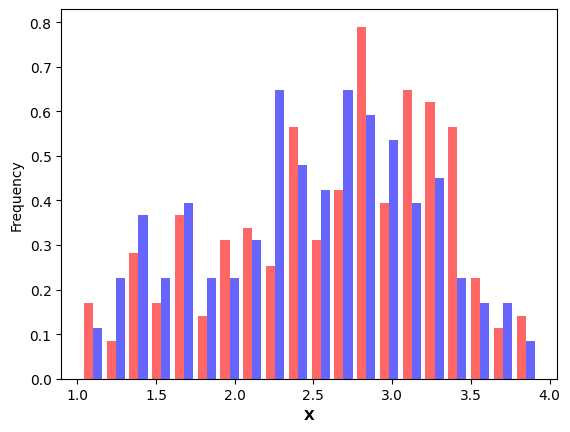

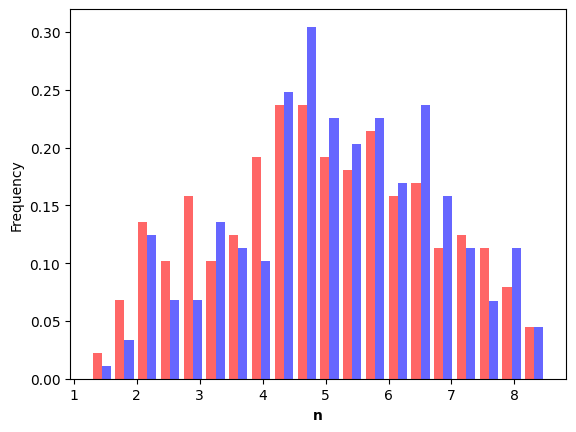

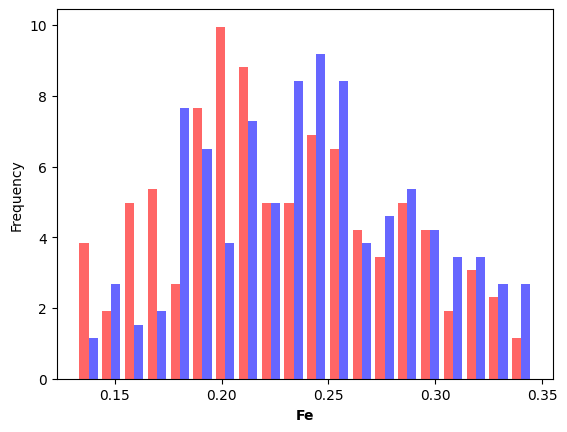

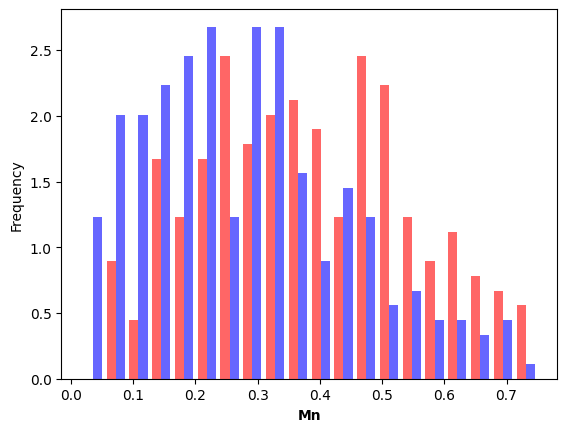

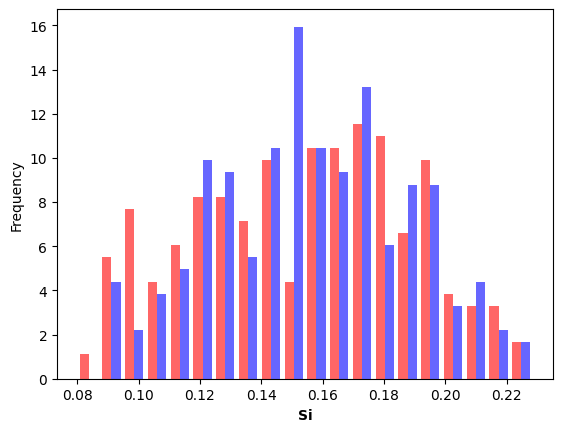

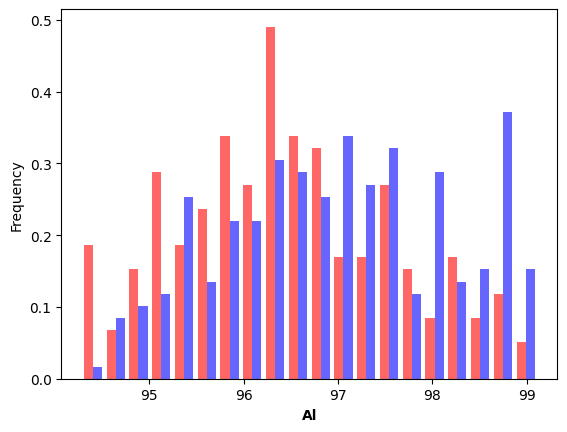

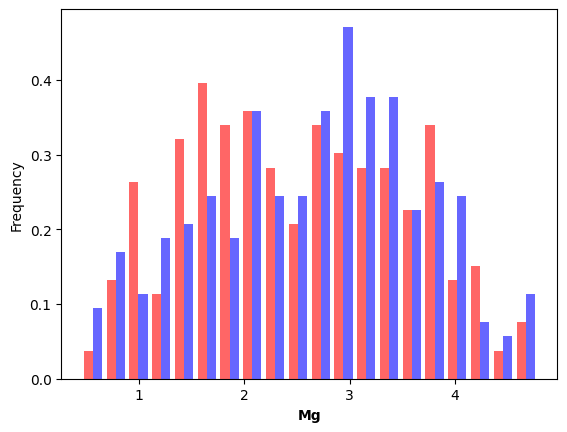

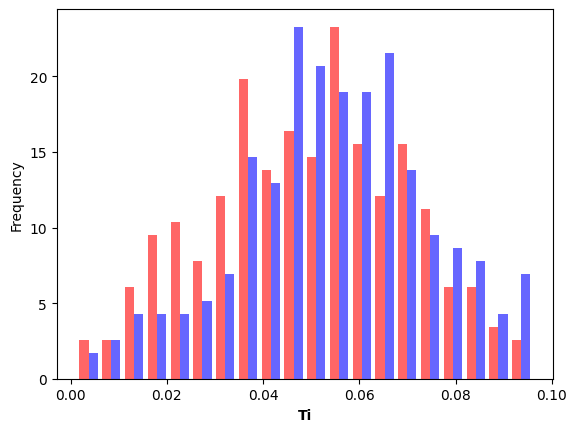

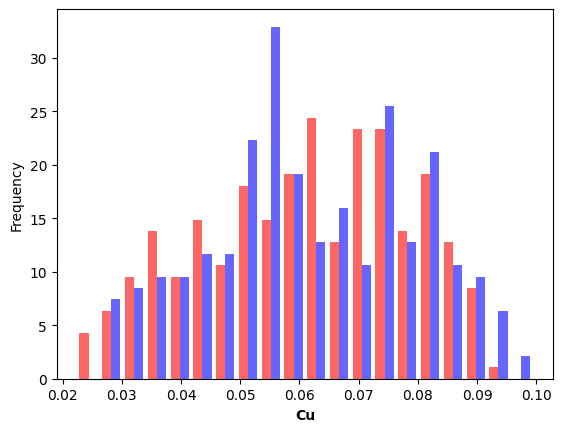

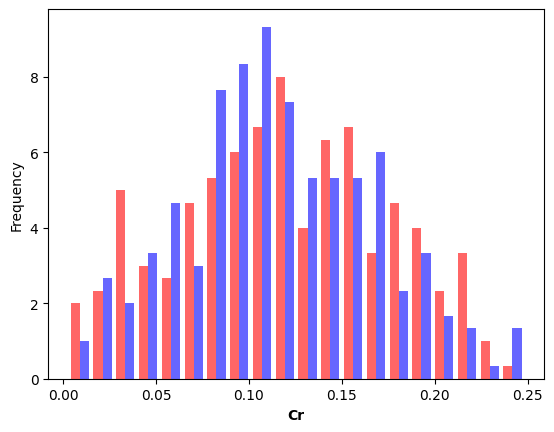

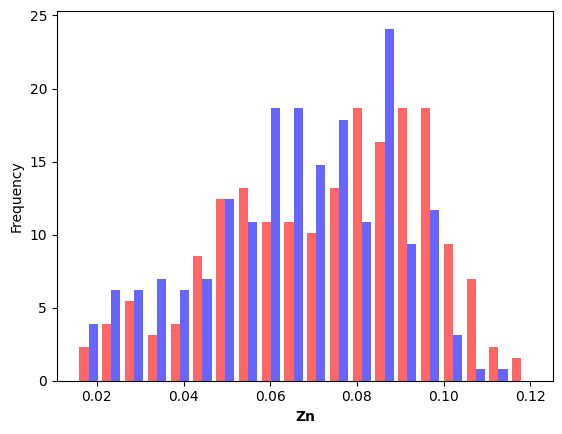

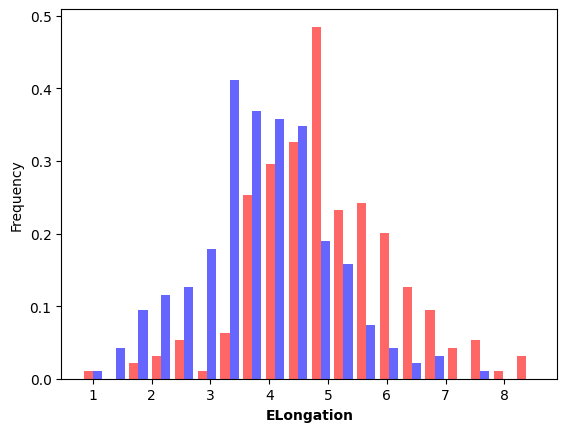

In [17]:
################################
######## create Figures ########
################################


import matplotlib.pyplot as plt


A = sampling_high
num_drop = int(len(A) * 0.3)
A = np.delete(A, range(num_drop), 0)

B = sampling_low
num_drop = int(len(B) * 0.3)
B = np.delete(B, range(num_drop), 0)

for i in range(len(A[0])):
    fig = plt.figure()
    plt.hist([A[:, i], B[:, i]], stacked=False, bins=20, color=['red', 'blue'], alpha=0.6, density=True)
    plt.xlabel(x_label[i], fontdict={'weight': 'bold'})
    plt.ylabel('Frequency')

    # Use a dynamic filename for each plot
    plot_filename = f'X{i}.pdf'

    # Save the figure
    plt.savefig(plot_filename)

    # Download the saved figure
    files.download(plot_filename)